# Fock-State Decoder — Phase 2a: encoder/decoder round-trip

Validates the qubit<->cavity transduction used by the lossy-beamsplitter
decoder, **before** adding the environment or the channel. We use the
already-validated single-qubit tomography (`StateTomography1QExperiment`) as the
read-out.

**Sequence per logical state L:**
```
input rotation (prepares cardinal qubit state)   ->  PREP_SEQS[L]
encoder  E      (qubit -> {|0>,|2>} cavity)        ->  build_encoder_seq
decoder  D=E^t  ({|0>,|2>} cavity -> qubit)        ->  build_decoder_seq
tomography (X/Y/Z) on the qubit
```
Because `E` then `D` cancel ideally, the round-trip should return the input
cardinal. So this checks:
1. `revert_pulse_seq` is a correct inverse,
2. the cavity excursion (e0-f0 / g0-e0 / f0-g1 / e1-f1 / f1-g2 ladder) is
   **coherent and reversible** — miscalibration or dephasing in those sideband
   pulses shows up as reduced round-trip fidelity,
3. full integration of a complex prepulse with the tomography read-out.

It does **not** prove the cavity actually holds the {|0>,|2>} state — that
absolute check is the Wigner-tomography cross-check in Phase 2b. Environment
(|1> in M1-S3) + partial beamsplitter come in 2b/2c.


## Setup

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from tqdm.notebook import tqdm
from pathlib import Path

import experiments as meas
from experiments.MM_dual_rail_base import MM_dual_rail_base
from experiments import MultimodeStation, CharacterizationRunner
from experiments.transduction.decoder import (
    build_encoder_seq, build_decoder_seq, revert_pulse_seq,
)
from fitting.state_tomography import state_fidelity, PX, PY, PZ

from slab import AttrDict
from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

db = get_database()
config_dir = str(Path.cwd().parent.parent / 'configs')
config_manager = ConfigVersionManager(config_dir)

client = JobClient()
health = client.health_check()
print(f"Server status: {health['status']}  pending: {health['pending_jobs']}")

user = "seb"
station = MultimodeStation(
    user=user,
    experiment_name="260601_FockDecoder_2a",
    project="Transduction",
    log_measurements=True,
)
USE_QUEUE = True

mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soccfg)

# Active reset that worked for you in the tomography notebook
active_reset_dict = {
    'active_reset': True,
    'ef_reset': True,
    'storage_reset': False,
    'coupler_reset': False,
    'pre_selection_reset': True,
    'man_reset': False,
    'use_qubit_man_reset': True,
    'pre_selection_parity': True,
}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Server status: healthy  pending: 1
[STATION] Using main hardware_config version: CFG-HW-20260601-00059
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using main man1_storage_swap version: CFG-M1-20260528-00074
[STATION] Using main floquet_storage_swap version: CFG-FL-20260223-00024
[STATION] Lab-notebook vault: G:\Shared drives\SLab\Multimode
Data, plots, logs will be stored in: C:\experiments\260601_FockDecoder_2a
Hardware configs will be read from C:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260601-00059.yml
dict_keys(['Pyro.NameServer', 'Qick101'])
QICK running on ZCU216, software version 0.2.291

Firmware configuration (built Tue Oct 15 12:06:51 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 us)
		fs=6389.760 MHz, fabric=399

## Build the encoder / decoder

`build_encoder_seq` derives the state-independent transduction `E` from the
lab's validated `prep_fock_state([0,2])` ladder (leading input rotation
stripped). `build_decoder_seq` is its inverse `D = E^dagger`
(`revert_pulse_seq`: reverse order + 180 deg phase).


In [4]:
MAN_NO = 1

E_seq = build_encoder_seq(mm_base_calib, man_no=MAN_NO)
D_seq = build_decoder_seq(mm_base_calib, man_no=MAN_NO)

print('Encoder E (qubit -> {|0>,|2>}):')
for g in E_seq:
    print('  ', g)
print('Decoder D = E^dagger:')
for g in D_seq:
    print('  ', g)

# Corrected cardinal prep phases (from Phase-1 tomography convention check):
# a ge hpi with phase phi takes |g> -> Bloch (-sin phi, -cos phi, 0).
PREP_SEQS = {
    '0':  [],
    '1':  [['qubit', 'ge', 'pi', 0]],
    '+':  [['qubit', 'ge', 'hpi', 270]],   # -> +X
    '-':  [['qubit', 'ge', 'hpi', 90]],    # -> -X
    '+i': [['qubit', 'ge', 'hpi', 180]],   # -> +Y
    '-i': [['qubit', 'ge', 'hpi', 0]],     # -> -Y
}

# logical L (cavity) maps to this qubit cardinal after decode
IDEAL_KETS = {
    '0':  np.array([1, 0], dtype=complex),
    '1':  np.array([0, 1], dtype=complex),
    '+':  np.array([1, 1], dtype=complex) / np.sqrt(2),
    '-':  np.array([1, -1], dtype=complex) / np.sqrt(2),
    '+i': np.array([1, 1j], dtype=complex) / np.sqrt(2),
    '-i': np.array([1, -1j], dtype=complex) / np.sqrt(2),
}

def bloch_vector(rho):
    return np.array([np.real(np.trace(rho @ PX)),
                     np.real(np.trace(rho @ PY)),
                     np.real(np.trace(rho @ PZ))])

def purity(rho):
    return float(np.real(np.trace(rho @ rho)))

Preparing state 0 and 2 with coeff 1.0
Preparing state 0 and 2 with coeff 1.0
Encoder E (qubit -> {|0>,|2>}):
   ['multiphoton', 'e0-f0', 'pi', 0]
   ['multiphoton', 'g0-e0', 'pi', 0]
   ['multiphoton', 'f0-g1', 'pi', 0]
   ['multiphoton', 'g0-e0', 'pi', 0]
   ['multiphoton', 'e1-f1', 'pi', 0]
   ['multiphoton', 'f1-g2', 'pi', 0]
Decoder D = E^dagger:
   ['multiphoton', 'f1-g2', 'pi', 180]
   ['multiphoton', 'e1-f1', 'pi', 180]
   ['multiphoton', 'g0-e0', 'pi', 180]
   ['multiphoton', 'f0-g1', 'pi', 180]
   ['multiphoton', 'g0-e0', 'pi', 180]
   ['multiphoton', 'e0-f0', 'pi', 180]


## Defaults + preprocessor + runner

`state_prep_seq = PREP_SEQS[L] + E_seq + D_seq` is the full "prepare the decoded
qubit state" prepulse; the tomography then rotates + reads the qubit.


In [5]:
decoder_defaults = AttrDict(dict(
    reps=2000,
    rounds=1,
    qubits=[0],
    logical_state='+',          # '0','1','+','-','+i','-i'
    state_prep_seq=[],          # filled by preproc
    tomo_phases={'X': 90, 'Y': 0},   # validated reconstruction rotations
    recon_method='fast',
    relax_delay=2500,
    # readout-error correction (optional): pull from single-shot calibration
    # confusion=station.hardware_cfg.device.readout.confusion_matrix_with_active_reset,
))
decoder_defaults.update(active_reset_dict)

def decoder_roundtrip_preproc(station, default_expt_cfg, **kwargs):
    cfg = deepcopy(default_expt_cfg)
    cfg.update(kwargs)
    L = cfg['logical_state']
    cfg.state_prep_seq = deepcopy(PREP_SEQS[L]) + deepcopy(E_seq) + deepcopy(D_seq)
    return cfg

decoder_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.StateTomography1QExperiment,
    default_expt_cfg=decoder_defaults,
    preprocessor=decoder_roundtrip_preproc,
    postprocessor=None,
    job_client=client,
    use_queue=USE_QUEUE,
)

## Smoke test — one logical state

Job submitted: JOB-20260601-00293 (queue position: 2)

[0.0s] Job JOB-20260601-00293: pending

[62.2s] Job JOB-20260601-00293: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00293_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 41%|███████████████▌                      | 818/2000 [00:02<00:02, 394.21it/s]
[84.4s] Job JOB-20260601-00293: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.23s/it]
Reconstructed rho:
[[0.5549+0.j     0.2084+0.3309j]
 [0.2084-0.3309j 0.4451+0.j    ]]
counts (n_g, n_e) per basis: {'Z': (1005, 806), 'X': (1280, 527), 'Y': (302, 1484)}
Saving C:\experiments\260601_FockDecoder_2a\data\JOB-20260601-00293_StateTomography1QExperiment.h5
[WORKER] Saving expt object to: C:\exp

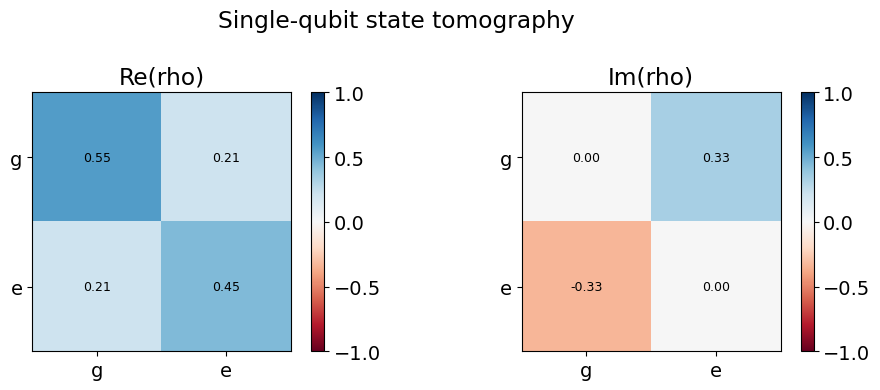

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[0.5549+0.j     0.2084+0.3309j]
 [0.2084-0.3309j 0.4451+0.j    ]]
counts (n_g, n_e) per basis: {'Z': (1005, 806), 'X': (1280, 527), 'Y': (302, 1484)}


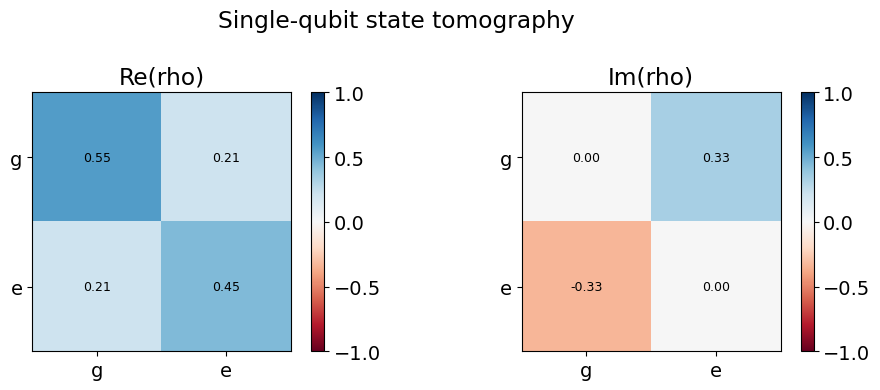

Bloch: [ 0.417 -0.662  0.11 ]  purity: 0.812
Round-trip fidelity to |+>: 0.7084


In [6]:
expt = decoder_runner.execute(logical_state='+', reps=2000)
expt.analyze()
expt.display()

rho = expt.data['rho']
print('Bloch:', np.round(bloch_vector(rho), 3), ' purity:', round(purity(rho), 3))
print('Round-trip fidelity to |+>:', round(state_fidelity(rho, IDEAL_KETS['+']), 4))

## All six logical states

logical states:   0%|          | 0/6 [00:00<?, ?it/s]

Job submitted: JOB-20260601-00296 (queue position: 2)

[0.0s] Job JOB-20260601-00296: pending

[38.2s] Job JOB-20260601-00296: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00296_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 61%|██████████████████████▋              | 1227/2000 [00:03<00:01, 396.36it/s]
[60.4s] Job JOB-20260601-00296: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.21s/it]
Reconstructed rho:
[[0.9727+0.j     0.011 -0.0017j]
 [0.011 +0.0017j 0.0273+0.j    ]]
counts (n_g, n_e) per basis: {'Z': (1747, 49), 'X': (909, 870), 'Y': (889, 883)}
Saving C:\experiments\260601_FockDecoder_2a\data\JOB-20260601-00296_StateTomography1QExperiment.h5
[WORKER] Saving expt object to: C:\experi

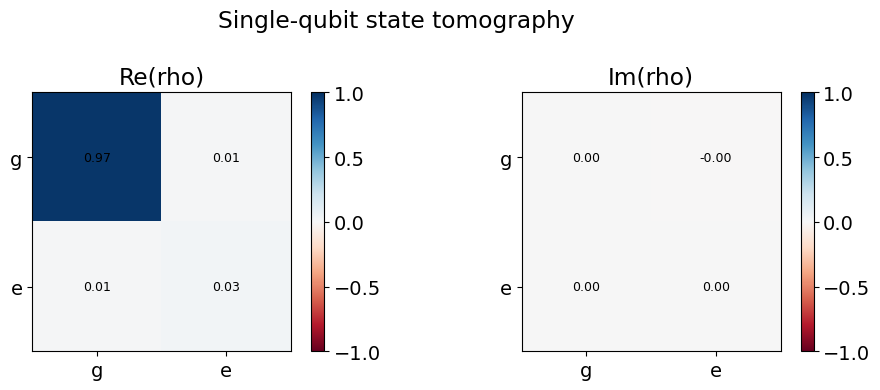

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[0.9727+0.j     0.011 -0.0017j]
 [0.011 +0.0017j 0.0273+0.j    ]]
counts (n_g, n_e) per basis: {'Z': (1747, 49), 'X': (909, 870), 'Y': (889, 883)}
Job submitted: JOB-20260601-00299 (queue position: 2)

[0.0s] Job JOB-20260601-00299: pending

[160.9s] Job JOB-20260601-00299: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00299_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 41%|███████████████▌                      | 818/2000 [00:02<00:02, 395.49it/s]
[183.0s] Job JOB-20260601-00299: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.24s/it]
Reconstructed rho:
[[ 0.0

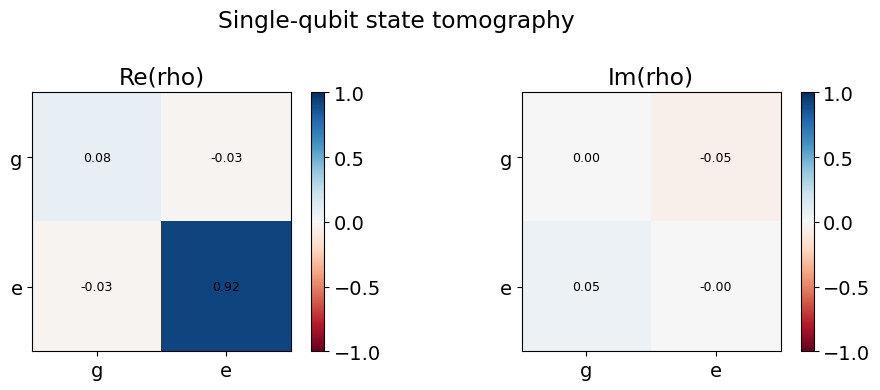

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[ 0.0813+0.j     -0.0287-0.0547j]
 [-0.0287+0.0547j  0.9187-0.j    ]]
counts (n_g, n_e) per basis: {'Z': (146, 1650), 'X': (853, 957), 'Y': (994, 798)}
Job submitted: JOB-20260601-00301 (queue position: 1)

[0.0s] Job JOB-20260601-00301: pending

[32.1s] Job JOB-20260601-00301: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00301_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 82%|██████████████████████████████▎      | 1636/2000 [00:04<00:00, 397.42it/s]
[56.3s] Job JOB-20260601-00301: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.24s/it]
Reconstructed rho:
[[0

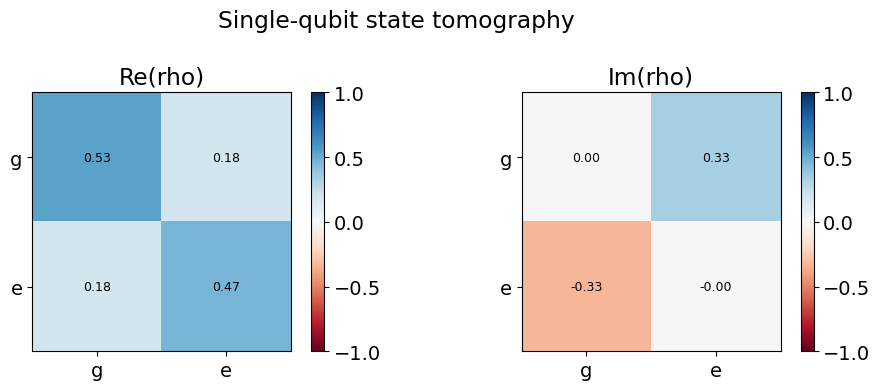

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[0.5343+0.j     0.1844+0.3305j]
 [0.1844-0.3305j 0.4657-0.j    ]]
counts (n_g, n_e) per basis: {'Z': (942, 821), 'X': (1232, 568), 'Y': (305, 1494)}
Job submitted: JOB-20260601-00303 (queue position: 1)

[0.0s] Job JOB-20260601-00303: pending

[30.1s] Job JOB-20260601-00303: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00303_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 61%|██████████████████████▋              | 1227/2000 [00:03<00:01, 395.64it/s]
[52.3s] Job JOB-20260601-00303: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.24s/it]
Reconstructed rho:
[[ 0.5

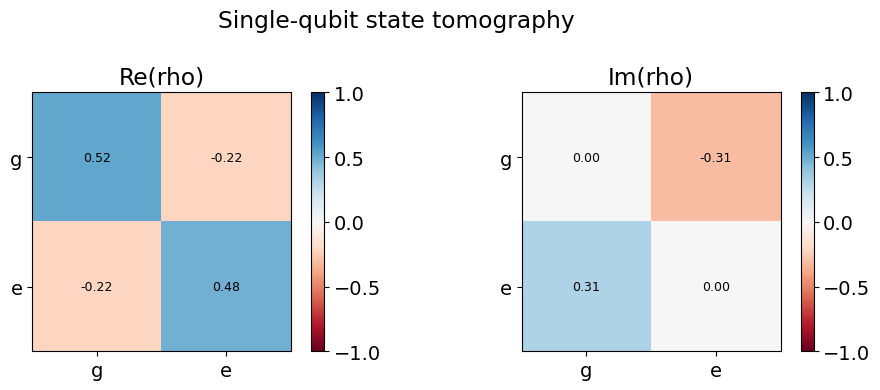

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[ 0.5215+0.j     -0.2166-0.3099j]
 [-0.2166+0.3099j  0.4785+0.j    ]]
counts (n_g, n_e) per basis: {'Z': (946, 868), 'X': (507, 1282), 'Y': (1461, 343)}
Job submitted: JOB-20260601-00305 (queue position: 1)

[0.0s] Job JOB-20260601-00305: pending

[30.1s] Job JOB-20260601-00305: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00305_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 41%|███████████████▌                      | 818/2000 [00:02<00:02, 395.38it/s]
[52.2s] Job JOB-20260601-00305: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.25s/it]
Reconstructed rho:
[[

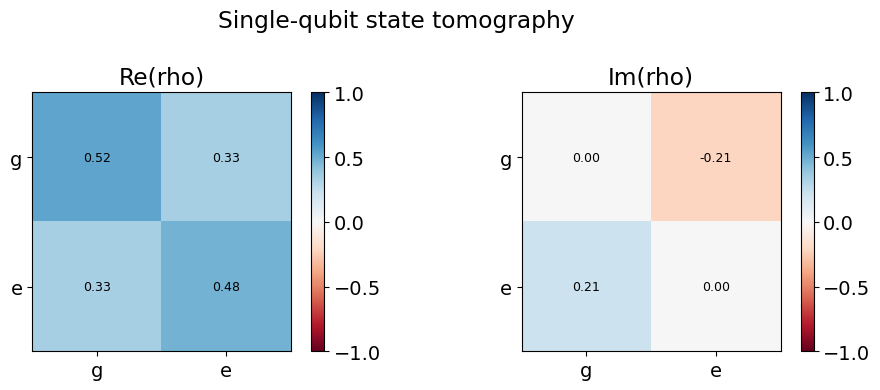

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[0.5241+0.j     0.3281-0.2124j]
 [0.3281+0.2124j 0.4759+0.j    ]]
counts (n_g, n_e) per basis: {'Z': (955, 867), 'X': (1460, 303), 'Y': (1271, 513)}
Job submitted: JOB-20260601-00307 (queue position: 1)

[0.0s] Job JOB-20260601-00307: pending

[30.1s] Job JOB-20260601-00307: running
[WORKER] Loading StateTomography1QExperiment from experiments.single_qubit.state_tomography_1q
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260601-00307_StateTomography1QExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.25mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 61%|██████████████████████▋              | 1227/2000 [00:03<00:01, 395.11it/s]
[54.2s] Job JOB-20260601-00307: completed
basis: 100%|█████████████████████████████████████| 3/3 [00:15<00:00,  5.23s/it]
Reconstructed rho:
[[ 0.5

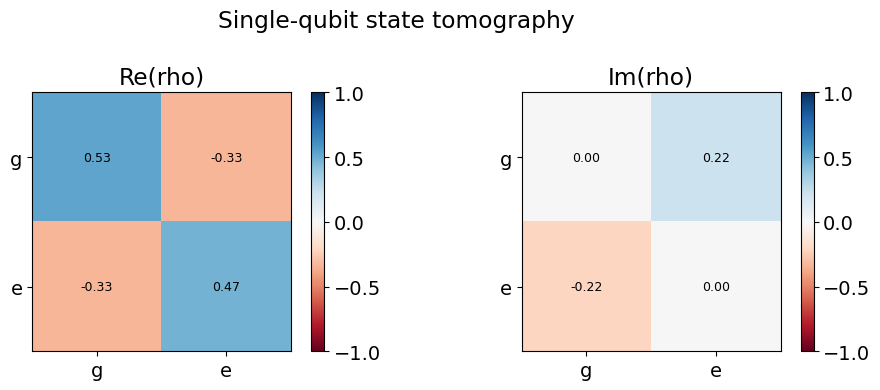

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\06\2026-06-01.md
Reconstructed rho:
[[ 0.5261+0.j     -0.3311+0.2162j]
 [-0.3311-0.2162j  0.4739+0.j    ]]
counts (n_g, n_e) per basis: {'Z': (946, 852), 'X': (309, 1520), 'Y': (514, 1297)}
   L      rx      ry      rz  purity     fid
   0   0.022   0.003   0.945   0.947  0.9727
   1  -0.057   0.109  -0.837   0.858  0.9187
   +   0.369  -0.661   0.069   0.789  0.6844
   -  -0.433   0.620   0.043   0.787  0.7166
  +i   0.656   0.425   0.048   0.807  0.7124
  -i  -0.662  -0.432   0.052   0.814  0.7162

mean round-trip fidelity: 0.7868


In [7]:
logicals = ['0', '1', '+', '-', '+i', '-i']
rhos, rows = {}, []

for L in tqdm(logicals, desc='logical states'):
    expt = decoder_runner.execute(logical_state=L, reps=2000)
    expt.analyze()
    rho = expt.data['rho']
    rhos[L] = rho
    b = bloch_vector(rho)
    fid = state_fidelity(rho, IDEAL_KETS[L])
    rows.append((L, b[0], b[1], b[2], purity(rho), fid))

print(f"{'L':>4} {'rx':>7} {'ry':>7} {'rz':>7} {'purity':>7} {'fid':>7}")
for L, rx, ry, rz, pur, fid in rows:
    print(f"{L:>4} {rx:7.3f} {ry:7.3f} {rz:7.3f} {pur:7.3f} {fid:7.4f}")
print(f"\nmean round-trip fidelity: {np.mean([r[5] for r in rows]):.4f}")

## Bloch-sphere view

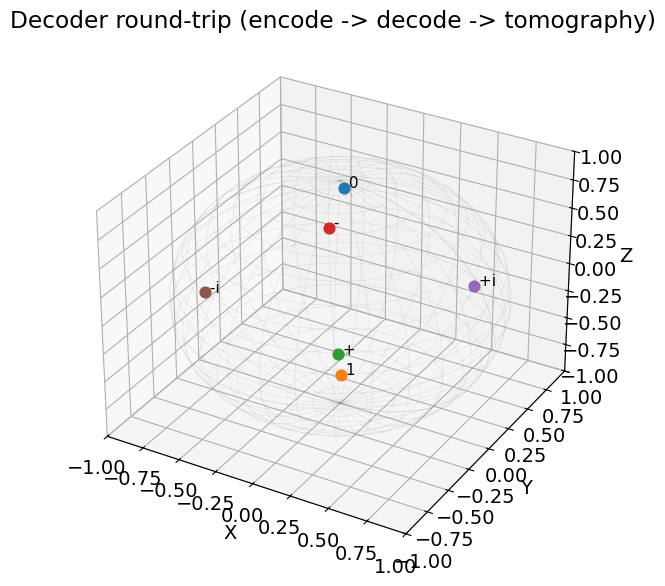

In [9]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:20j]
ax.plot_wireframe(np.cos(u)*np.sin(v), np.sin(u)*np.sin(v), np.cos(v),
                  color='gray', alpha=0.15, linewidth=0.5)
for L in logicals:
    b = bloch_vector(rhos[L])
    ax.scatter(*b, s=60)
    ax.text(b[0], b[1], b[2], f' {L}', fontsize=11)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1]); ax.set_zlim([-1, 1])
ax.set_title('Decoder round-trip (encode -> decode -> tomography)')
plt.tight_layout(); plt.show()

## Notes / next (Phase 2b)

- High round-trip fidelity here = the transduction ladder is coherent and the
  encode/decode inversion is correct. Lower fidelity on the superposition
  logicals (`+`,`-`,`+i`,`-i`) vs the poles (`0`,`1`) points at f0-g1 / f1-g2
  phase or dephasing issues.
- Cavity reset: `active_reset_dict` uses `use_qubit_man_reset` (man_reset is
  off), so the manipulate mode relies on the coherent round-trip returning to
  vacuum + `relax_delay`. If residual cavity population biases results, try
  enabling `man_reset` (read_num auto-adjusts via `lane_layout`).
- **Phase 2b** adds: |1> environment in **M1-S3**, the length-scaled partial
  beamsplitter (eta = cos^2(theta/2)), and the parity syndrome readout, plus a
  Wigner-tomography cross-check that the encoder really makes {|0>,|2>}.
